# Part 3: Customer Segmentation

## Goal

This exercise groups customers into three segments based on annual spending, purchase frequency, age, and region. The groups can help a business tailor marketing messages and offers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Data source/reference: Kaggle Mall Customers dataset
# https://www.kaggle.com/datasets/shwetabh123/mall-customers
# The published dataset inspired the variables used here. This reproducible
# educational version contains 300 records for a more meaningful clustering task.

rng = np.random.default_rng(21)
n = 300
age = rng.integers(18, 71, n)
purchase_frequency = rng.integers(2, 31, n)
annual_spending = np.round((purchase_frequency * rng.normal(95, 18, n) + rng.normal(500, 900, n)).clip(250, 8500), 2)
region = rng.choice(["West", "Central", "East", "South"], n)

customer_data = pd.DataFrame({
    "annual_spending": annual_spending,
    "purchase_frequency": purchase_frequency,
    "age": age,
    "region": region,
})
customer_data.to_csv("customer_segmentation_realistic.csv", index=False)
customer_data = pd.read_csv("customer_segmentation_realistic.csv")
print(f"Records loaded: {len(customer_data)}")
customer_data.head()

Records loaded: 300


,annual_spending,purchase_frequency,age,region
0,727.82,12,33,Central
1,250.00,2,59,South
2,1383.88,23,38,East
3,2156.10,14,50,South
4,3245.06,14,42,East


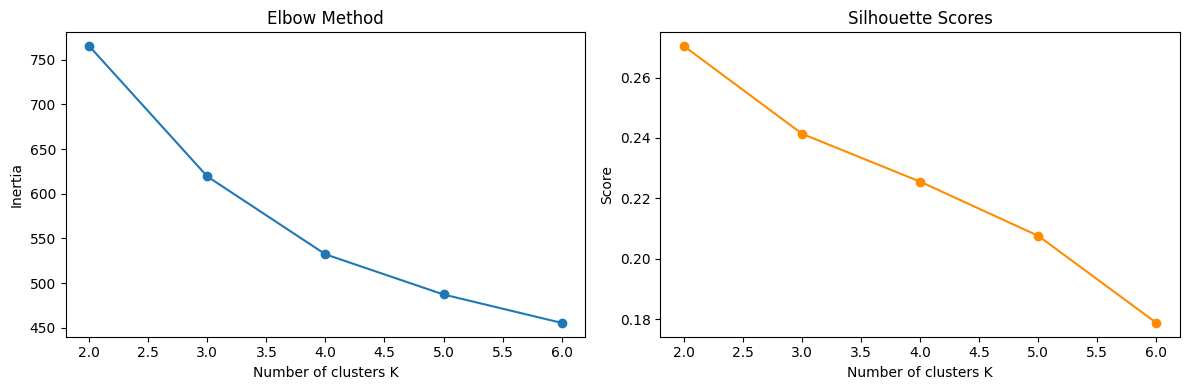

 K  silhouette_score
 2             0.270
 3             0.241
 4             0.226
 5             0.208
 6             0.179


In [2]:
numerical_features = ["annual_spending", "purchase_frequency", "age"]
categorical_features = ["region"]
preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numerical_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
X = preprocessor.fit_transform(customer_data)

inertias = []
silhouette_scores = []
for k in range(2, 7):
    candidate = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = candidate.fit_predict(X)
    inertias.append(candidate.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(2, 7), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters K")
axes[0].set_ylabel("Inertia")
axes[1].plot(range(2, 7), silhouette_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel("Number of clusters K")
axes[1].set_ylabel("Score")
plt.tight_layout()
plt.savefig("elbow_plot.png", dpi=150)
plt.show()
print(pd.DataFrame({"K": range(2, 7), "silhouette_score": silhouette_scores}).round(3).to_string(index=False))

In [3]:
# K=3 gives an interpretable balance of separation and useful business groups.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_data["cluster"] = kmeans.fit_predict(X)

cluster_summary = customer_data.groupby("cluster").agg({
    "annual_spending": "mean",
    "purchase_frequency": "mean",
    "age": "mean",
    "region": lambda values: values.mode()[0],
    "cluster": "size",
}).rename(columns={"cluster": "customer_count"})
print("Cluster profiles:")
print(cluster_summary.round(1).to_string())

for cluster_id, row in cluster_summary.iterrows():
    spending = row["annual_spending"]
    frequency = row["purchase_frequency"]
    if spending >= customer_data["annual_spending"].median() and frequency >= customer_data["purchase_frequency"].median():
        strategy = "VIP rewards, early access, and premium bundles"
    elif frequency >= customer_data["purchase_frequency"].median():
        strategy = "Loyalty points and personalized repeat-purchase offers"
    else:
        strategy = "Introductory discounts, reminders, and educational content"
    print(f"Cluster {cluster_id}: {strategy}")

customer_data.to_csv("customer_segments.csv", index=False)
print("\nSaved customer_segments.csv and elbow_plot.png")

Cluster profiles:
         annual_spending  purchase_frequency   age region  customer_count
cluster                                                                  
0                 1468.6                10.1  58.1  South              93
1                 1545.3                11.3  30.4   East              98
2                 3320.6                24.0  45.4   East             109
Cluster 0: Introductory discounts, reminders, and educational content
Cluster 1: Introductory discounts, reminders, and educational content
Cluster 2: VIP rewards, early access, and premium bundles

Saved customer_segments.csv and elbow_plot.png


### Interpretation

The elbow plot shows how within-cluster variation decreases as K increases, while the silhouette plot helps compare how well-separated the groups are. K=3 was selected because it creates three understandable customer profiles without making the segments unnecessarily narrow. The marketing strategies are based on each cluster's average spending and purchase frequency and should be tested against actual campaign results.